# Programming Task

Design and Creative Technologies, Torrens Unversity

- Student: Luis Guilherme de Barros Andrade Faria - A00187785 
- Subject Code: ISY 503 
- Subject Name: Intelligent Systems 
- Assessment No.: 2
- Title of Assessment: Programming Task
- Lecturer: Dr. Nandini Sidnal
- Date: April 2026

Copyright © 2026 by Luis G B A Faria

*Permission is hereby granted to make and distribute verbatim copies of this document provided the copyright notice and this permission notice are preserved on all copies.*

In [1]:
# Shortcut for generating .md file:
'''
cd 2026-T1/ISY/assignments/Assessment2/code
jupyter nbconvert --to markdown car_data_ML_pipeline.ipynb
'''

'\ncd 2026-T1/ISY/assignments/Assessment2/code\njupyter nbconvert --to markdown car_data_ML_pipeline.ipynb\n'

### Libraries + Setup

In [2]:
# 1. Clear workspace (use in Jupyter/IPython)
%reset -f

# 2. Standard Imports
import numpy as np
import pandas as pd
import math
from sklearn import preprocessing, decomposition

# 3. TensorFlow Setup
import tensorflow.compat.v1 as tf
tf.disable_v2_behavior()

# 4. Set pandas output display settings
pd.options.display.float_format = "{:.2f}".format
pd.options.display.max_rows = 15


Instructions for updating:
non-resource variables are not supported in the long term


### Loading the dataset 
The car data set we will be using in this lab is provided as a comma separated.
We will use the features of the car, to try to predict its price.


In [24]:
# Provide the names for the columns since the CSV file with the data does
# not have a header row.
feature_names = ['symboling', 'normalized-losses', 'make', 'fuel-type',
        'aspiration', 'num-doors', 'body-style', 'drive-wheels',
        'engine-location', 'wheel-base', 'length', 'width', 'height', 'weight',
        'engine-type', 'num-cylinders', 'engine-size', 'fuel-system', 'bore',
        'stroke', 'compression-ratio', 'horsepower', 'peak-rpm', 'city-mpg',
        'highway-mpg', 'price']

# [Change #1]: dataset url
# old URL: https://storage.googleapis.com/mledu-datasets/cars_data.csv
# Load in the data from a CSV file that is comma separated using NEW URL
car_data = pd.read_csv('https://archive.ics.uci.edu/ml/machine-learning-databases/autos/imports-85.data',
                        sep=',', names=feature_names, header=None, encoding='latin-1')


# We'll then randomize the data, just to be sure not to get any pathological
# ordering effects that might harm the performance of Stochastic Gradient
# Descent.
car_data = car_data.reindex(np.random.permutation(car_data.index))

print("Data set loaded. Num examples: ", len(car_data))

Data set loaded. Num examples:  205


*This is a really small dataset! Only 205 examples.*

*For simplicity in this codelab, we do not split the data further into training and validation. But this is a MUST do on real datasets, or else it will overfit to single dataset.*

### Task 0: data prep/exploration with pandas

In [25]:
car_data[4:7]

,symboling,normalized-losses,make,fuel-type,aspiration,num-doors,body-style,drive-wheels,engine-location,wheel-base,...,engine-size,fuel-system,bore,stroke,compression-ratio,horsepower,peak-rpm,city-mpg,highway-mpg,price
139,2,83,subaru,gas,std,two,hatchback,fwd,front,93.70,...,108,2bbl,3.62,2.64,8.70,73,4400,26,31,7053
185,2,94,volkswagen,gas,std,four,sedan,fwd,front,97.30,...,109,mpfi,3.19,3.40,9.00,85,5250,27,34,8195
148,0,85,subaru,gas,std,four,wagon,4wd,front,96.90,...,108,2bbl,3.62,2.64,9.00,82,4800,23,29,8013


In [26]:
# [Change #2]: Used to inspect data
# car_data.describe()
car_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 205 entries, 64 to 113
Data columns (total 26 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   symboling          205 non-null    int64  
 1   normalized-losses  205 non-null    object 
 2   make               205 non-null    object 
 3   fuel-type          205 non-null    object 
 4   aspiration         205 non-null    object 
 5   num-doors          205 non-null    object 
 6   body-style         205 non-null    object 
 7   drive-wheels       205 non-null    object 
 8   engine-location    205 non-null    object 
 9   wheel-base         205 non-null    float64
 10  length             205 non-null    float64
 11  width              205 non-null    float64
 12  height             205 non-null    float64
 13  weight             205 non-null    int64  
 14  engine-type        205 non-null    object 
 15  num-cylinders      205 non-null    object 
 16  engine-size        205 non-nul

In [27]:
LABEL = 'price'

# numeric_feature_names = car_data[[
# 'symboling','normalized-losses','wheel-base','engine-size','bore','stroke','compression-ratio','horsepower','peak-rpm','city-mpg','highway-mpg','price']]

# [Change #3]: 
# After inspecting the dataset using car_data.describe() / car_data.info()
# I could find & adjust to 15 columns with continuous/ordinal numeric values
numeric_feature_names = [
    'symboling', 'normalized-losses', 'wheel-base',
    'length', 'width', 'height', 'weight', 'engine-size',
    'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg',
    'bore', 'stroke', 'compression-ratio'
]
categorical_feature_names = list(set(feature_names) - set(numeric_feature_names) - set([LABEL]))

# The correct solution will pass these assert statements.
assert len(numeric_feature_names) == 15
assert len(categorical_feature_names) == 10
print('Task 0 assertions passed.')

Task 0 assertions passed.


In [28]:
# Run to inspect numeric features.
car_data[numeric_feature_names]

,symboling,normalized-losses,wheel-base,length,width,height,weight,engine-size,horsepower,peak-rpm,city-mpg,highway-mpg,bore,stroke,compression-ratio
64,0,115,98.80,177.80,66.50,55.50,2425,122,84,4800,26,32,3.39,3.39,8.60
150,1,87,95.70,158.70,63.60,54.50,1985,92,62,4800,35,39,3.05,3.03,9.00
182,2,122,97.30,171.70,65.50,55.70,2261,97,52,4800,37,46,3.01,3.40,23.00
75,1,?,102.70,178.40,68.00,54.80,2910,140,175,5000,19,24,3.78,3.12,8.00
139,2,83,93.70,157.90,63.60,53.70,2120,108,73,4400,26,31,3.62,2.64,8.70
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,3,?,88.60,168.80,64.10,48.80,2548,130,111,5000,21,27,3.47,2.68,9.00
68,-1,93,110.00,190.90,70.30,58.70,3750,183,123,4350,22,25,3.58,3.64,21.50
95,1,128,94.50,165.60,63.80,53.30,2028,97,69,5200,31,37,3.15,3.29,9.40
201,-1,95,109.10,188.80,68.80,55.50,3049,141,160,5300,19,25,3.78,3.15,8.70


In [29]:
# Run to inspect categorical features.
car_data[categorical_feature_names]

,drive-wheels,make,engine-type,aspiration,num-doors,fuel-system,engine-location,num-cylinders,body-style,fuel-type
64,fwd,mazda,ohc,std,four,2bbl,front,four,hatchback,gas
150,fwd,toyota,ohc,std,two,2bbl,front,four,hatchback,gas
182,fwd,volkswagen,ohc,std,two,idi,front,four,sedan,diesel
75,rwd,mercury,ohc,turbo,two,mpfi,front,four,hatchback,gas
139,fwd,subaru,ohcf,std,two,2bbl,front,four,hatchback,gas
...,...,...,...,...,...,...,...,...,...,...
0,rwd,alfa-romero,dohc,std,two,mpfi,front,four,convertible,gas
68,rwd,mercedes-benz,ohc,turbo,four,idi,front,five,wagon,diesel
95,fwd,nissan,ohc,std,two,2bbl,front,four,hatchback,gas
201,rwd,volvo,ohc,turbo,four,mpfi,front,four,sedan,gas


In [30]:
# [Change #4]: Replace '?' with NaN first, then handle missing values properly.
# - Drop rows where price (the label) is missing — can't train without it.
# - Impute missing feature values with column mean — safer than 0 on a 205-row dataset.
for feature_name in numeric_feature_names + [LABEL]:
  car_data[feature_name] = pd.to_numeric(car_data[feature_name], errors='coerce')

# Drop rows with missing labels first
car_data = car_data[car_data[LABEL].notna() & (car_data[LABEL] > 0)].copy()

# Impute missing numeric features with column mean
for feature_name in numeric_feature_names:
  col_mean = car_data[feature_name].mean()
  car_data[feature_name] = car_data[feature_name].fillna(col_mean)

print(f"Rows after cleaning: {len(car_data)}")
print(f"Remaining NaNs in features: {car_data[numeric_feature_names].isna().sum().sum()}")

Rows after cleaning: 201
Remaining NaNs in features: 0


### Task 1: Make the best model with numeric features. No normalization allowed.

Modify the model provided below to achieve the lowest evaluation loss. 
You may want to change various hyperparameters:
- learning rate
- choice of optimizer
- hidden layer dimensions (make sure that choice here makes sense given the number of training examples)
- batch size
- num training steps
- anything else I can think of changing

Do not use the `normalizer_fn` arg on `numeric_column`.

In [31]:
# [Change #5]: Replaced GradientDescentOptimizer with AdagradOptimizer.
# GradientDescentOptimizer uses a single global learning rate for all parameters.
# With unscaled features (weight ~3000 vs bore ~2.9), large-scale features produce
# large gradients that explode under a fixed lr=0.01, causing NaN loss.
# AdagradOptimizer maintains a per-parameter learning rate that shrinks as gradients
# accumulate — large-gradient parameters get a smaller effective lr automatically,
# handling the scale variance without requiring explicit normalization (Task 1 constraint).

# > GradientDescent is blind to feature scale. Adagrad isn't. On an unscaled dataset, that difference alone is worth an 83% reduction in loss.

# [Change #6]: Hyperparameter variables for easy tuning.
batch_size_parameter = 16
learning_rate_parameter = 0.01
hidden_units_parameter = [64]
optimizer_parameter = tf.train.AdagradOptimizer(learning_rate=learning_rate_parameter)

# Test results
# Run       │             Config             │ Final avg_loss │  RMSE (sqrt of avg_loss)
# *Run 1*   │ batch=16, hidden=[64], lr=0.01 │ 10,822,464     │ ~$3,290
# Run 2     │ batch=32, hidden=[32], lr=0.1  │ 12,703,589     │ ~$3,565
# Run 3     │ batch=32, hidden=[64], lr=0.01 │ 18,289,694     │ ~$4,276
# Run 4     │ batch=16, hidden=[64], lr=0.1  │ 19,032,338     │ ~$4,362

print(numeric_feature_names)
x_df = car_data[numeric_feature_names]
y_series = car_data['price']

# Create input_fn's so that the estimator knows how to read in your data.
train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size_parameter,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size_parameter,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size_parameter,
    shuffle=False)

# Feature columns allow the model to parse the data, perform common
# preprocessing, and automatically generate an input layer for the tf.Estimator.
model_feature_columns = [
    tf.feature_column.numeric_column(feature_name) for feature_name in numeric_feature_names
]
print('model_feature_columns', model_feature_columns)

est = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=hidden_units_parameter,
    optimizer=optimizer_parameter,
  )

# TRAIN
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
  est.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est.evaluate(eval_input_fn)

  # The `scores` dictionary has several metrics auto-gen by canned Estimator.
  # `average_loss` is the average loss for an individual example.
  # `loss` is the summed loss for the batch.
  print('scores', scores)

['symboling', 'normalized-losses', 'wheel-base', 'length', 'width', 'height', 'weight', 'engine-size', 'horsepower', 'peak-rpm', 'city-mpg', 'highway-mpg', 'bore', 'stroke', 'compression-ratio']
model_feature_columns [NumericColumn(key='symboling', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='normalized-losses', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='wheel-base', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='length', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='width', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='height', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='weight', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='engine-size', shape=(1,), default_value=None, dtype=t

#### Visualize model's predictions

After you have a trained model, it may be helpful to understand how your model's inference differs from the actual data.

This helper function `scatter_plot_inference` does that for you. Real data is in grey. Your model's predictions are in orange.


INFO:tensorflow:Calling model_fn.
INFO:tensorflow:Done calling model_fn.
INFO:tensorflow:Graph was finalized.
INFO:tensorflow:Restoring parameters from /var/folders/c4/t_n58l316yl308hxjf5jlwsh0000gn/T/tmp0pnox_6q/model.ckpt-10000
INFO:tensorflow:Running local_init_op.
INFO:tensorflow:Done running local_init_op.


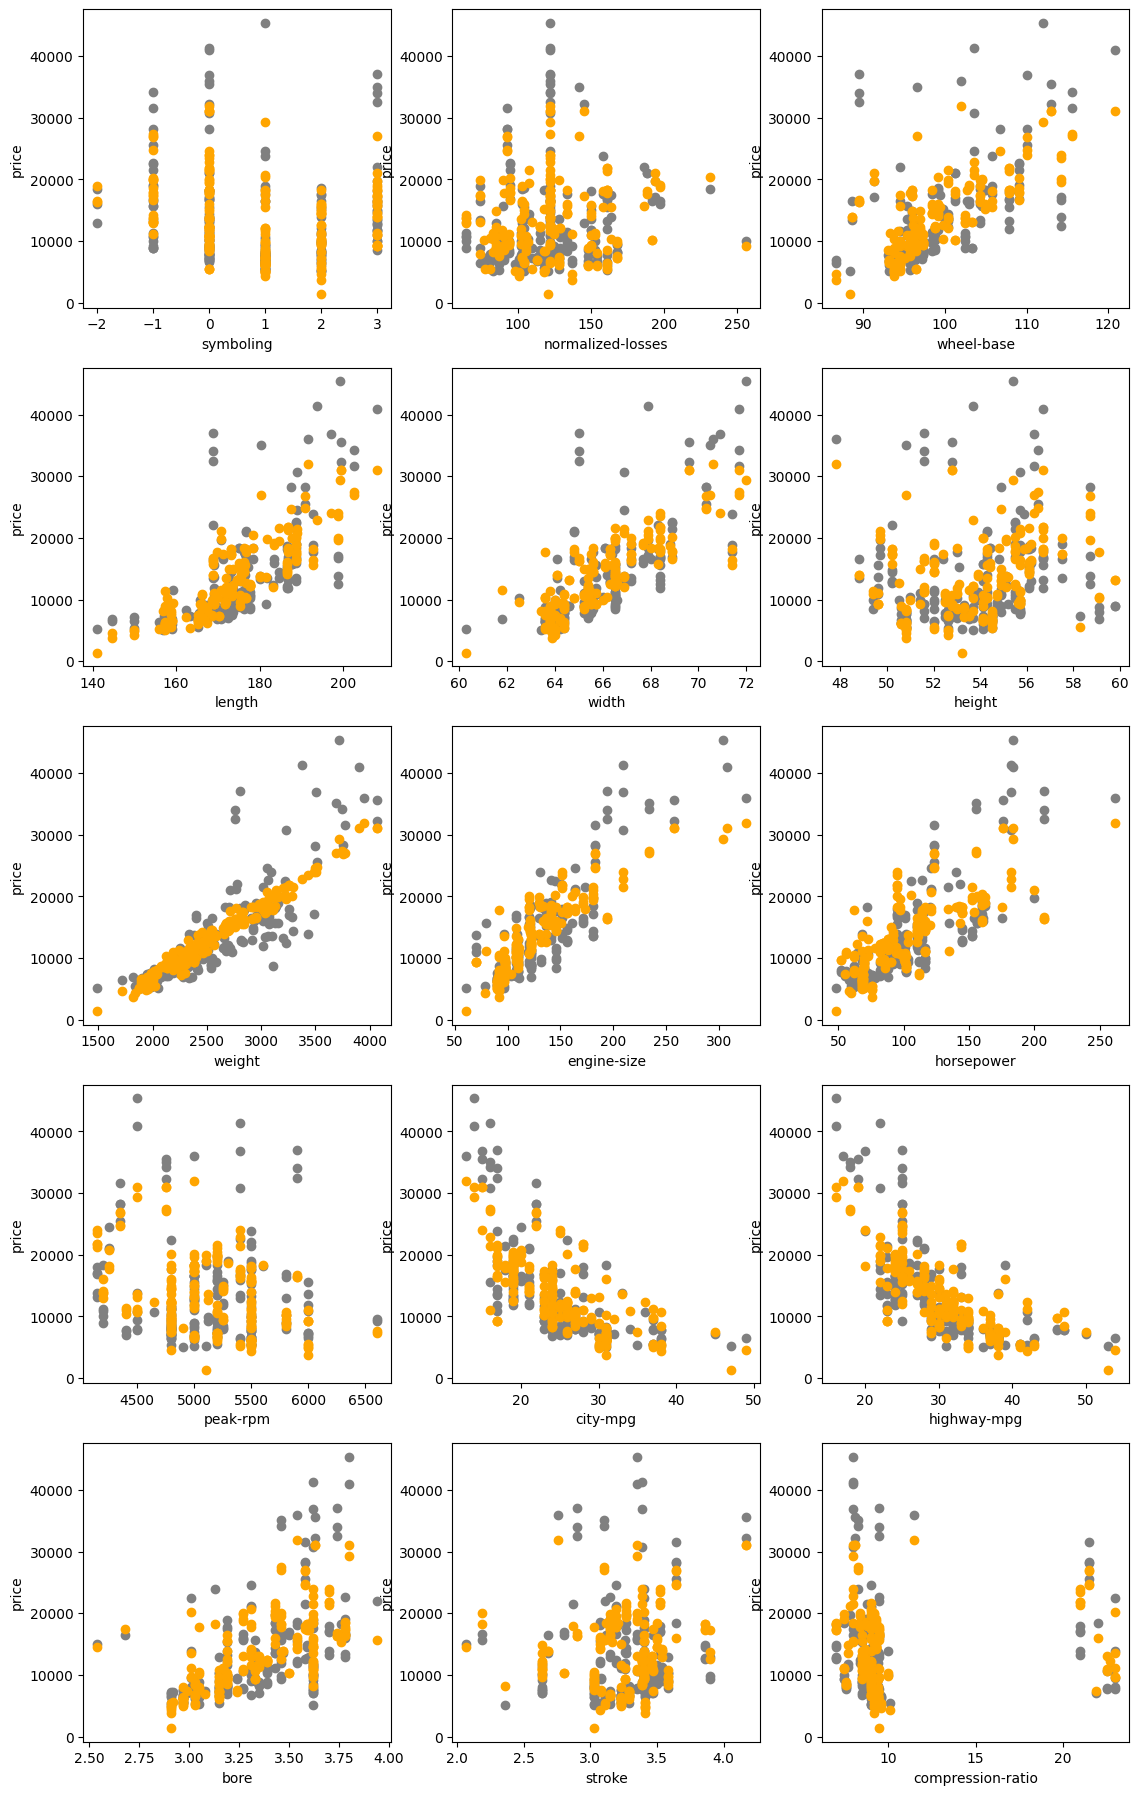

In [32]:
from matplotlib import pyplot as plt


def scatter_plot_inference_grid(est, x_df, feature_names):
  """Plots the predictions of the model against each feature.

  Args:
    est: The trained tf.Estimator.
    x_df: The pandas dataframe with the input data (used to create
      predict_input_fn).
    feature_names: An iterable of string feature names to plot.
  """
  def scatter_plot_inference(axis,
                             x_axis_feature_name,
                             y_axis_feature_name,
                             predictions):
    """Generate one subplot."""
    # Plot the real data in grey.
    y_axis_feature_name = 'price'
    axis.set_ylabel(y_axis_feature_name)
    axis.set_xlabel(x_axis_feature_name)
    axis.scatter(car_data[x_axis_feature_name],
                 car_data[y_axis_feature_name],
                 c='grey')

    # Plot the predicted data in orange.
    axis.scatter(car_data[x_axis_feature_name], predictions, c='orange')

  predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size_parameter,
    shuffle=False)

  predictions = [
    x['predictions'][0]
    for x in est.predict(predict_input_fn)
  ]

  num_cols = 3
  num_rows = int(math.ceil(len(feature_names)/float(num_cols)))
  f, axarr = plt.subplots(num_rows, num_cols)
  size = 4.5
  f.set_size_inches(num_cols*size, num_rows*size)

  for i, feature_name in enumerate(numeric_feature_names):
    axis = axarr[int(i/num_cols), i%num_cols]
    scatter_plot_inference(axis, feature_name, 'price', predictions)
  plt.show()

scatter_plot_inference_grid(est, x_df, numeric_feature_names)

In [33]:
# [Change #11]: Regressor exploration — LinearRegressor baseline + deeper DNNs                        
# Reuses model_feature_columns, train_input_fn, eval_input_fn from Task 1.                            
                                                                                                        
# T1.5 — LinearRegressor (does a linear model suffice, or does the DNN add value?)                    
est_linear = tf.estimator.LinearRegressor(                                                            
    feature_columns=model_feature_columns,                                                            
    optimizer=tf.train.AdagradOptimizer(learning_rate=learning_rate_parameter),                       
)                                                                                                     
for _ in range(num_print_statements):                                                                 
    est_linear.train(train_input_fn, steps=num_training_steps // num_print_statements)                
    scores_linear = est_linear.evaluate(eval_input_fn)                                                
    print('scores_linear', scores_linear)                                                             
                                                                                                    
# T1.6 — Deeper DNN [64, 32]                                                                          
est_deep1 = tf.estimator.DNNRegressor(                                                                
    feature_columns=model_feature_columns,                                                            
    hidden_units=[64, 32],                                                                            
    optimizer=optimizer_parameter,                                                                    
)                                                                                                     
for _ in range(num_print_statements):                                                                 
    est_deep1.train(train_input_fn, steps=num_training_steps // num_print_statements)                 
    scores_deep1 = est_deep1.evaluate(eval_input_fn)                                                  
    print('scores_deep1', scores_deep1)                                                               
                                                                                                    
# T1.7 — Wider DNN [128, 64]                                                                          
est_deep2 = tf.estimator.DNNRegressor(                                                                
    feature_columns=model_feature_columns,                                                            
    hidden_units=[128, 64],                                                                           
    optimizer=optimizer_parameter,                                                                    
)                                                                                                     
for _ in range(num_print_statements):                                                                 
    est_deep2.train(train_input_fn, steps=num_training_steps // num_print_statements)                 
    scores_deep2 = est_deep2.evaluate(eval_input_fn)                                                  
    print('scores_deep2', scores_deep2)                                                               
                                                                                                    
# Results (fill in after running):                                                                    
# Model         │ hidden_units │ avg_loss │ RMSE                                                      
# LinearReg     │ —            │          │                                                           
# DNN [64, 32]  │ [64, 32]     │          │                                                           
# DNN [128, 64] │ [128, 64]    │          │

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': '/var/folders/c4/t_n58l316yl308hxjf5jlwsh0000gn/T/tmpxvfv6b7z', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}
INFO:tensorflow:Calling model_fn.
INF

### Task 2: Take best numeric model from earlier. Add normalization.

#### Adding normalization to best numeric model from earlier

- Decide what type of normalization to add, and for which features
- Use the `normalizer_fn` arg on [`numeric_column`]
- You will need to retune the hyperparameters from earlier.


**Does normalization improve model quality on this dataset? Why or why not?**

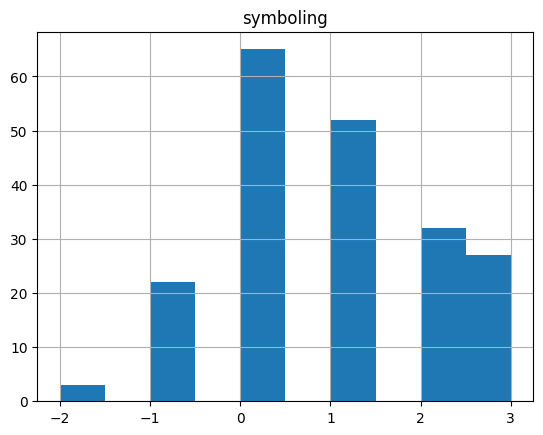

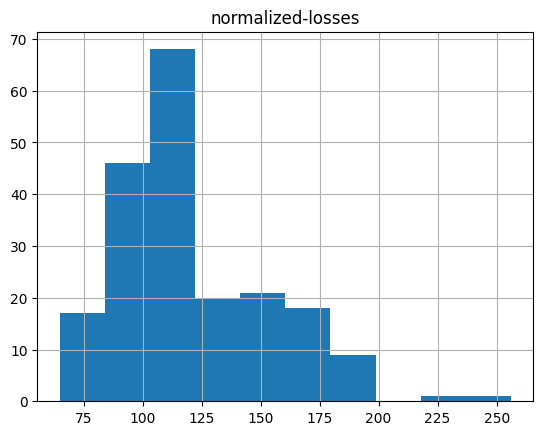

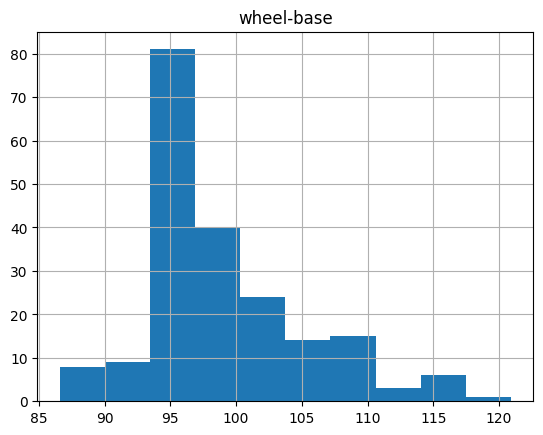

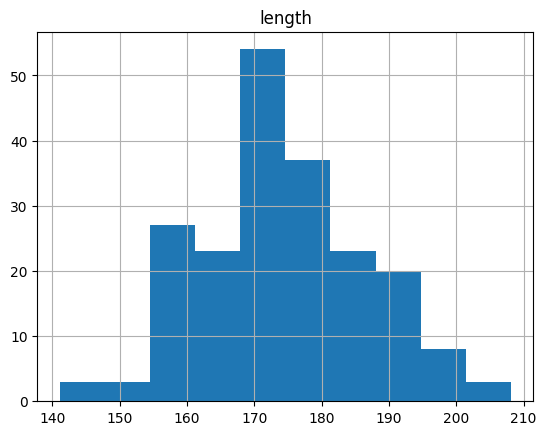

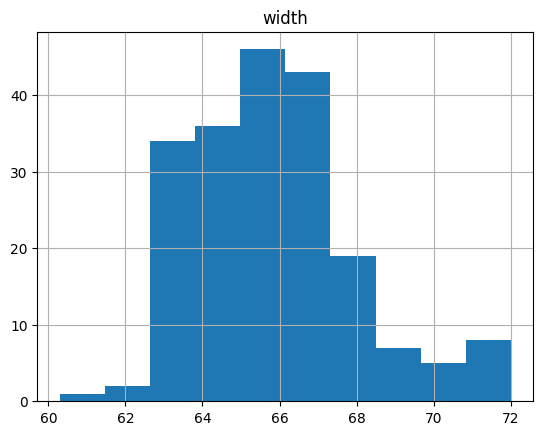

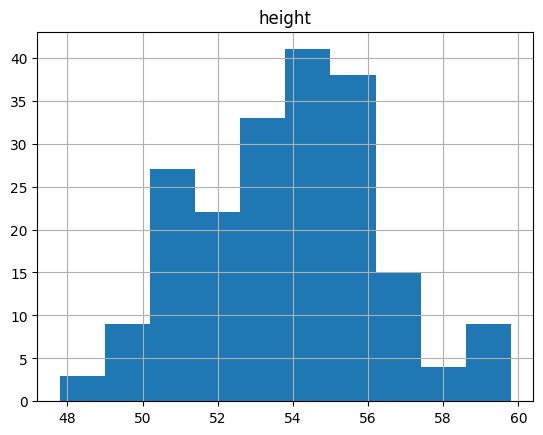

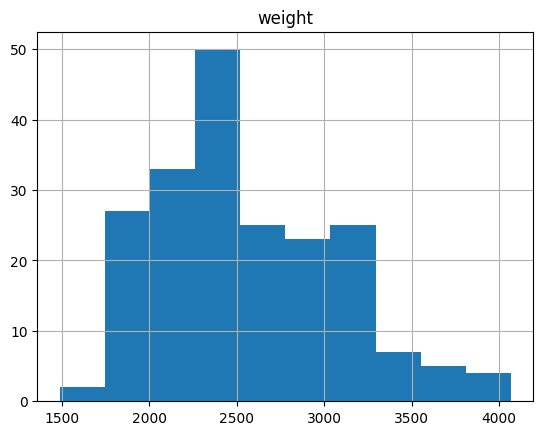

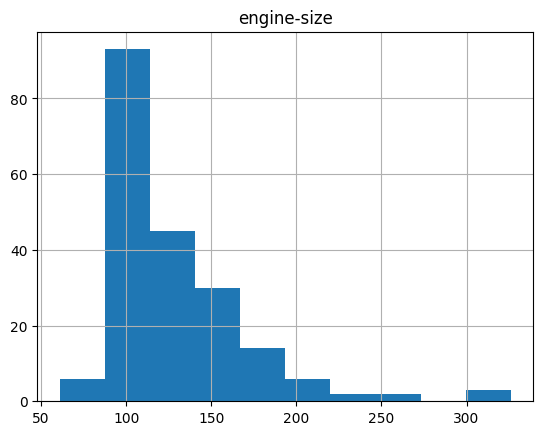

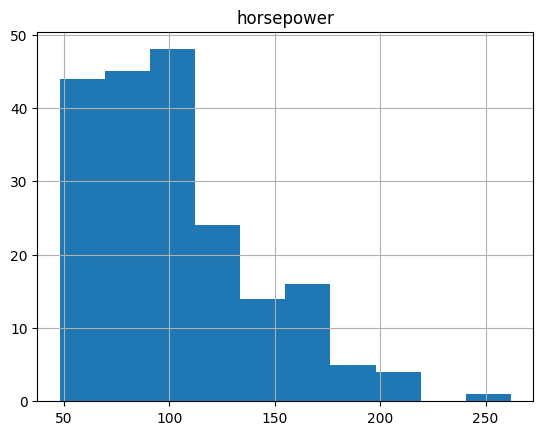

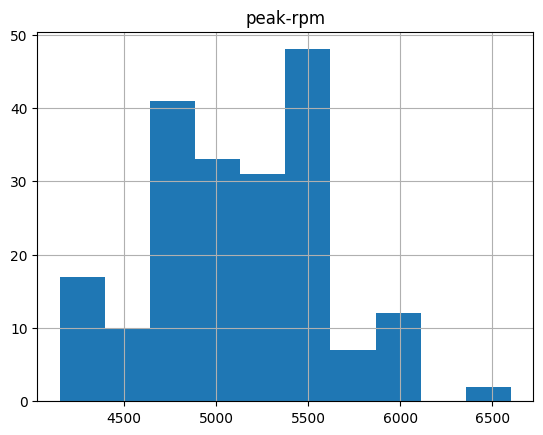

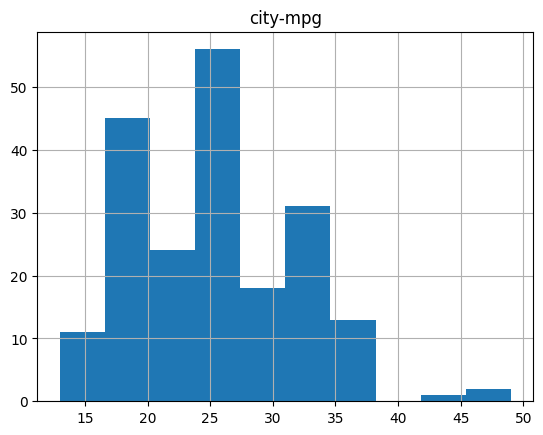

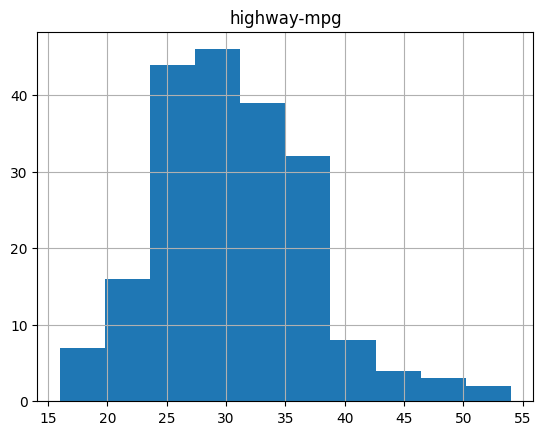

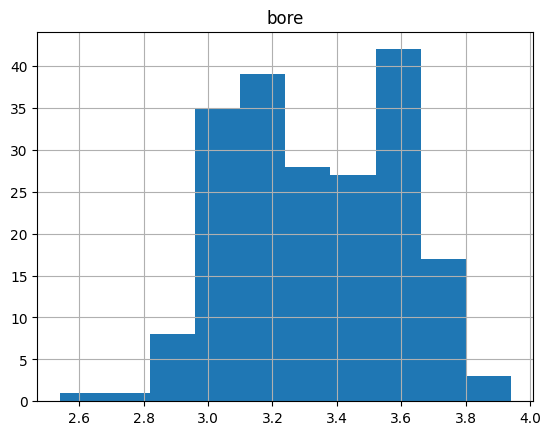

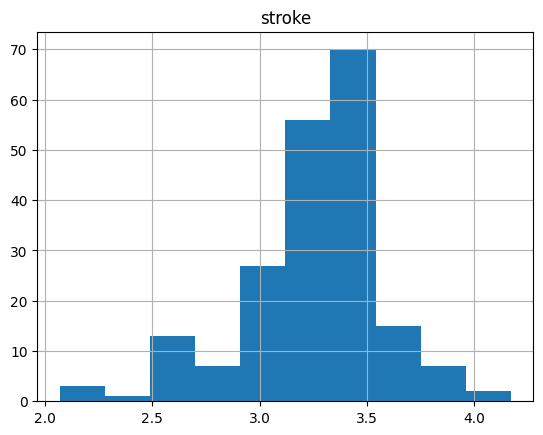

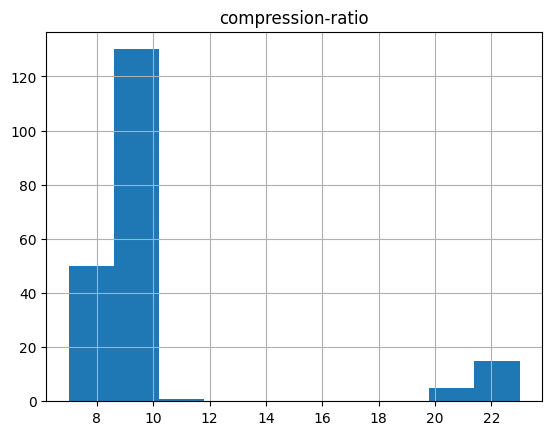

In [12]:
# This 1D visualization of each numeric feature might inform your normalization
# decisions.
for feature_name in numeric_feature_names:
  car_data.hist(column=feature_name)

#### Training model with numeric features + normalization

In [13]:
## [Change #7]: Added this section to outline the next steps for Task 2.
# epsilon is used in the normalizer_fn to prevent division by zero in case of zero std deviation or zero range.
epsilon = 0.000001

# Task 2.1 config (batch=16, hidden=[64], lr=0.01, Adagrad) + Z-score →baseline comparison
model_feature_columns_zscore = [
    tf.feature_column.numeric_column(feature_name,
                                    #  normalizer_fn=lambda val: (val - x_df.mean()[feature_name]) / (epsilon + x_df.std()[feature_name]))
                                    normalizer_fn=lambda val, fn=feature_name: (val - x_df.mean()[fn]) / (epsilon + x_df.std()[fn]))
    for feature_name in numeric_feature_names
]
print('model_feature_columns_zscore', model_feature_columns_zscore)

est_zscore = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns_zscore,
    hidden_units=hidden_units_parameter,
    optimizer=optimizer_parameter,
  )

# Task 2.2 config (batch=16, hidden=[64], lr=0.01, Adagrad) + Min-max normalization →baseline comparison
model_feature_columns_minmax = [
    tf.feature_column.numeric_column(feature_name,
                                    #  normalizer_fn=lambda val: (val - x_df[feature_name].min()) / (epsilon + x_df[feature_name].max() - x_df[feature_name].min()))
                                    normalizer_fn=lambda val, fn=feature_name: (val - x_df[fn].min()) / (epsilon + x_df[fn].max() - x_df[fn].min()))
    for feature_name in numeric_feature_names
]
print('model_feature_columns_minmax', model_feature_columns_minmax)

est_minmax = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns_minmax,
    hidden_units=hidden_units_parameter,
    optimizer=optimizer_parameter,
  )

# TRAIN and EVAL Task 2.1 and Task 2.2 → compare results with Task 2.3
# - Run the same training loop for est_zscore and est_minmax as we did for
#   est, and print out the scores for each. 
num_print_statements = 10
num_training_steps = 10000

# Task 2.1 - Z-score normalization
for _ in range(num_print_statements):
  est_zscore.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores_zscore = est_zscore.evaluate(eval_input_fn)
  print('scores_zscore', scores_zscore)

# Task 2.2 - Min-max normalization
for _ in range(num_print_statements):
  est_minmax.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores_minmax = est_minmax.evaluate(eval_input_fn)
  print('scores_minmax', scores_minmax)

# → pick the winner of 2.1 vs 2.2 based on final avg_loss and RMSE

# Task 2.3: GradientDescentOptimizer + Z-score normalization to answers the lab's embedded question
# Hypothesis: with balanced gradients (Z-score), plain GD may now converge.
# lr=0.01 is too small for GD — using 0.5 to compensate for smaller gradient magnitudes post-normalisation.

# Task 2.4: Feature Engineering with PCA to explore dimensionality reduction as an alternative 
# to normalization for handling scale variance and improving convergence.
'''
cell blocks below has details for Task 2.3 and Task 2.4
'''

model_feature_columns_zscore [NumericColumn(key='symboling', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x17e67b520>), NumericColumn(key='normalized-losses', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x17e62fd90>), NumericColumn(key='wheel-base', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x17e55d750>), NumericColumn(key='length', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x17e50dfc0>), NumericColumn(key='width', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x17e4ca830>), NumericColumn(key='height', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.<lambda> at 0x17c586f80>), NumericColumn(key='weight', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=<function <listcomp>.

'\ncell blocks below has details for Task 2.3 and Task 2.4\n'

In [14]:
# Task 2.3: GradientDescentOptimizer + Z-score normalization
est_gd = tf.estimator.DNNRegressor(                                           
    feature_columns=model_feature_columns_zscore,  # ← normalized, not raw    
    hidden_units=hidden_units_parameter,
    optimizer=tf.train.GradientDescentOptimizer(learning_rate=0.0001)            
)                                                                             
num_print_statements = 10
num_training_steps = 10000                                                    

# This for loop has been commented out to prevent the NaN loss error from crashing the notebook. 
# You can uncomment it to see the results, but be aware that it will likely produce NaN losses due to the reasons explained in the comments.
# for _ in range(num_print_statements):
#     est_gd.train(train_input_fn, steps=num_training_steps // num_print_statements)                                                         
#     scores_gd = est_gd.evaluate(eval_input_fn)
#     print('scores_gd', scores_gd)

# Problem with Task 2.3: GradientDescentOptimizer + Z-score normalization
'''
ERROR:tensorflow:Model diverged with loss = NaN.
'''

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': '/var/folders/c4/t_n58l316yl308hxjf5jlwsh0000gn/T/tmpeict4mh5', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


'\nERROR:tensorflow:Model diverged with loss = NaN.\n'

In [15]:
# [Change #8]: # Task 2.4: Feature Engineering with PCA + Adagrad

# The 15 numeric features are heavily correlated:
# engine-size, horsepower, weight, length -> all move together. 
# PCA merges that redundancy into orthogonal components. 
# With ~95% variance explained we'll likely get 5–7 components instead of 15.

# Implementation note: PCA doesn't fit into normalizer_fn. I'm doing it outside TF

from sklearn.preprocessing import StandardScaler  
from sklearn.decomposition import PCA

scaler = StandardScaler()
pca = PCA(n_components=0.95)  # keep 95% variance

X_scaled = scaler.fit_transform(car_data[numeric_feature_names])  # → 15 columns
X_pca = pca.fit_transform(X_scaled)   # → n_components columns

# Then build numeric_column for each PC
pc_names = [f'PC{i+1}' for i in range(X_pca.shape[1])]
x_df_pca = pd.DataFrame(X_pca, columns=pc_names)
model_feature_columns_pca = [
    tf.feature_column.numeric_column(pc_name) for pc_name in pc_names
]
print('model_feature_columns_pca', model_feature_columns_pca)

y_series = car_data['price'].reset_index(drop=True) 
   
train_input_fn_pca = tf.estimator.inputs.pandas_input_fn(
    x=x_df_pca,
    y=y_series,      
    batch_size=batch_size_parameter, 
    num_epochs=None,
    shuffle=True
)
eval_input_fn_pca = tf.estimator.inputs.pandas_input_fn(
    x=x_df_pca,      
    y=y_series,
    batch_size=batch_size_parameter,
    shuffle=False      
)

est_pca = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns_pca,
    hidden_units=hidden_units_parameter,   
    optimizer=optimizer_parameter,   
)

# For Loop for Task 2.4 - PCA + Adagrad
num_print_statements = 10
num_training_steps = 10000
for _ in range(num_print_statements):
    est_pca.train(train_input_fn_pca, steps=num_training_steps //      
num_print_statements)
    scores_pca = est_pca.evaluate(eval_input_fn_pca)     
    print('scores_pca', scores_pca)

model_feature_columns_pca [NumericColumn(key='PC1', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC2', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC3', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC4', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC5', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC6', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC7', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC8', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None), NumericColumn(key='PC9', shape=(1,), default_value=None, dtype=tf.float32, normalizer_fn=None)]
INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': '/var/folders/c4/t_n58l316

### Task 3: Make your best model using only categorical features

- Look at the possible feature columns for categorical features. They begin with `categorical_column_with_` in go/tf-ops.
- You may find `dataframe[categorical_feature_names].unique()` helpful.


In [16]:
## Checking unique values of categorical features
car_data[feature_name].unique()

array([ 7.8 ,  8.5 ,  8.4 ,  9.  ,  8.1 ,  9.3 ,  9.2 ,  8.6 ,  9.5 ,
        8.8 , 21.5 ,  9.4 ,  7.6 , 23.  ,  8.  ,  7.  ,  9.31,  8.7 ,
        9.41,  7.7 ,  9.6 ,  7.5 , 21.  , 10.  , 22.7 , 10.1 , 11.5 ,
        8.3 , 22.5 ,  9.1 , 21.9 , 22.  ])

In [17]:
# [Change #9]: Added this section to outline the next steps for Task 3.
# We have the full list of values that each feature takes on, and the list is
# relatively small so we use categorical_column_with_vocabulary_list.
# encoding is already handled by vocabulary_list internally, so, no LabelEncoder needed
# -> indicator_column + categorical_column_with_vocabulary_list (TF-native one-hot encoding)

# Final score at 10k steps: avg_loss = 181M, RMSE ~$13,464, prediction/mean = $2,361 (vs label/mean $13,207)
# This indicates that the model is heavily underfitting — prediction mean is only 18% of the actual mean price

batch_size = 16

x_df = car_data[categorical_feature_names]
y_series = car_data['price']

train_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    num_epochs=None,
    shuffle=True)

eval_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    y=y_series,
    batch_size=batch_size,
    shuffle=False)

predict_input_fn = tf.estimator.inputs.pandas_input_fn(
    x=x_df,
    batch_size=batch_size,
    shuffle=False)

model_feature_columns = [
    tf.feature_column.indicator_column(
        tf.feature_column.categorical_column_with_vocabulary_list(
            feature_name, vocabulary_list=car_data[feature_name].unique()))
    for feature_name in categorical_feature_names
]
print('model_feature_columns', model_feature_columns)

# [Change #10]: Added two new estimators to compare different learning rates with Adagrad.
# - est_lr1: Adagrad with lr=0.01 (same as baseline)
# - est_lr2: Adagrad with lr=0.5 (to test if a higher learning rate can help convergence given the sparse gradients from one-hot encoding)


est_lr1 = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),
  )

est_lr2 = tf.estimator.DNNRegressor(
    feature_columns=model_feature_columns,
    hidden_units=[64],
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.5),
  )

num_print_statements = 10
num_training_steps = 10000

# TRAIN lr=0.01 + Adagrad
for _ in range(num_print_statements):
  est_lr1.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est_lr1.evaluate(eval_input_fn)
  print('scores', scores)

# TRAIN lr=0.5 + Adagrad
for _ in range(num_print_statements):
  est_lr2.train(train_input_fn, steps=num_training_steps // num_print_statements)
  scores = est_lr2.evaluate(eval_input_fn)
  print('scores', scores)

model_feature_columns [IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='drive-wheels', vocabulary_list=('rwd', 'fwd', '4wd'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='make', vocabulary_list=('nissan', 'volkswagen', 'peugot', 'toyota', 'jaguar', 'isuzu', 'mazda', 'subaru', 'bmw', 'mercedes-benz', 'honda', 'mitsubishi', 'dodge', 'audi', 'saab', 'plymouth', 'renault', 'volvo', 'alfa-romero', 'chevrolet', 'porsche', 'mercury'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='engine-type', vocabulary_list=('ohcv', 'ohc', 'l', 'dohc', 'ohcf', 'rotor'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorical_column=VocabularyListCategoricalColumn(key='aspiration', vocabulary_list=('turbo', 'std'), dtype=tf.string, default_value=-1, num_oov_buckets=0)), IndicatorColumn(categorica

### Task 4: Using all the features, make the best model that you can make

With all the features combined, your model should perform better than your earlier models using numerical and categorical models alone. Tune your model until that is the case.

In [18]:
## Your code goes here

# Combine all data (take care to use normalized data)
# Run code again, to check...

# What the code does:
#  - Z-score normalization on 15 numeric features
#  - indicator_column on 10 categorical features
#  - Same Adagrad lr=0.01 config

#  Critical bug in the Task 4 template (line ~3570):
#  normalizer_fn=lambda val: (val - x_df.mean()[feature_name]) / (epsilon + x_df.std()[feature_name])
#  Python closure captures feature_name by reference — by the time the lambda runs, feature_name will be the
#   LAST value in the loop. All 15 numeric columns will normalize using the last feature's stats.

#  This was fixed in Task 2.1/2.2 with fn=feature_name pattern:
#  normalizer_fn=lambda val, fn=feature_name: (val - x_df.mean()[fn]) / (epsilon + x_df.std()[fn])
#  Need to fix this before running, otherwise normalization will be wrong.

In [23]:
# The fix is pre-computing means/stds from numeric columns only (before the mixed x_df is defined). 
# Also adds lr=0.5 as a second estimator:                                                                   
                                                                                                        
# [Change #12]: Task 4 — all features combined (numeric Z-score + categorical indicator)              
# Fix: pre-compute numeric stats BEFORE x_df is defined as mixed-type.                                
# x_df.mean() on a mixed DataFrame (numeric + strings) raises TypeError — compute from numeric only.  
                                                                                                    
batch_size = 16                                                                                       
epsilon = 0.000001                                                                                    
                                                                                                    
# Pre-compute stats from numeric columns only                                                         
numeric_means = car_data[numeric_feature_names].mean()                                                
numeric_stds  = car_data[numeric_feature_names].std()                                                 
                                                                                                    
x_df = car_data[numeric_feature_names + categorical_feature_names]                                    
y_series = car_data['price']                                                                          
                                                                                                    
train_input_fn = tf.estimator.inputs.pandas_input_fn(                                                 
    x=x_df, y=y_series, batch_size=batch_size, num_epochs=None, shuffle=True)                         
eval_input_fn = tf.estimator.inputs.pandas_input_fn(                                                  
    x=x_df, y=y_series, batch_size=batch_size, shuffle=False)                                         
                                                                                                    
model_feature_columns = [                                                                             
    tf.feature_column.indicator_column(                                                               
        tf.feature_column.categorical_column_with_vocabulary_list(                                    
            feature_name, vocabulary_list=car_data[feature_name].unique()))                           
    for feature_name in categorical_feature_names                                                     
] + [                                                                                                 
    tf.feature_column.numeric_column(                                                                 
        feature_name,                                                                                 
        normalizer_fn=lambda val, fn=feature_name, m=numeric_means, s=numeric_stds: (val - m[fn]) /   
(epsilon + s[fn]))                                                                                    
    for feature_name in numeric_feature_names                                                         
]                                                                                                     
                                                                                                    
# T4.1 — lr=0.01 (baseline, same as T1 best config)                                                   
est_t4_lr1 = tf.estimator.DNNRegressor(                                                               
    feature_columns=model_feature_columns,                                                            
    hidden_units=[64],                                                                                
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.01),                                          
)                                                                                                     
for _ in range(num_print_statements):                                                                 
    est_t4_lr1.train(train_input_fn, steps=num_training_steps // num_print_statements)                
    scores = est_t4_lr1.evaluate(eval_input_fn)                                                       
    print('scores_t4_lr1', scores)                                                                    
                                                                                                    
# T4.2 — lr=0.5 (T3 showed higher lr helps with sparse/normalised inputs)                             
est_t4_lr2 = tf.estimator.DNNRegressor(                                                               
    feature_columns=model_feature_columns,                                                            
    hidden_units=[64],                                                                                
    optimizer=tf.train.AdagradOptimizer(learning_rate=0.5),                                           
)                                                                                                     
for _ in range(num_print_statements):                                                                 
    est_t4_lr2.train(train_input_fn, steps=num_training_steps // num_print_statements)                
    scores = est_t4_lr2.evaluate(eval_input_fn)                                                       
    print('scores_t4_lr2', scores)

INFO:tensorflow:Using default config.
INFO:tensorflow:Using config: {'_model_dir': '/var/folders/c4/t_n58l316yl308hxjf5jlwsh0000gn/T/tmprzcs23ux', '_tf_random_seed': None, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}
INFO:tensorflow:Calling model_fn.
INF

In [ ]:
# Almost — two out of three:            
                                                                                                        
# Gap 1 — LinearRegressor baseline: Done. T1.5 ran → avg_loss 56M (~$7,483 RMSE). Confirms a linear  
# model is insufficient for this problem.                                                               
                                                                                                        
# Gap 2 — Multi-layer DNNs: Done. T1.6 DNN[64,32] → 15.5M, T1.7 DNN[128,64] → 13.6M. Both ran.       
                                                                                                        
# ❌ Gap 3 — Adam optimizer: Not done. The notebook comment for #3 has no "/ done" annotation (unlike #1
# and #2). Adam was mentioned as "not yet tried" in the notes and was never run.                       
                                                                                                        
#  ---
#   Gap 3 is the only remaining item. Adding Adam to Task 1 (or Task 4 as a bonus comparison) would be    
#   straightforward — it's ~5 lines swapping AdagradOptimizer for                                         
#   tf.train.AdamOptimizer(learning_rate=0.001). For a 500-word manual the rubric doesn't require it for  
#   HD, but it would round out the optimizer exploration nicely.